# 2. PCA, the two generative models, and how well they work

Two ways to turn 449 simulated devices into an unlimited supply of realistic ones:

**Method A — covariance (`GaussianModel`).** Fit a multivariate normal to the
empirical mean and full covariance matrix. Every pairwise correlation is kept;
the model stores `p(p+1)/2` numbers.

**Method B — dominant PCA (`PCAModel`).** Standardize, keep only the `k` leading
principal components ("disorder modes"), sample independent Gaussians along them
and map back. Sub-dominant modes are set to zero, so the generated cloud lives on
a `k`-dimensional subspace. The model stores `k*p` numbers and is interpretable:
each mode is a named physical distortion of the device.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))  # so `import chargetwin` works from notebooks/

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import chargetwin as ct

In [2]:
PARAMS = ct.FIG5_PARAMETERS
DATASET = "rho1e10"
N_SAMPLES = 500
SEED = 0

raw = ct.load_dataset(DATASET, PARAMS)
raw.shape

(449, 7)

## The PCA: how many modes do you actually need?

Over 80% of the device-to-device variance sits in just three modes.

Text(0.5, 1.0, 'rho1e10: top 3 modes = 85.3% of variance')

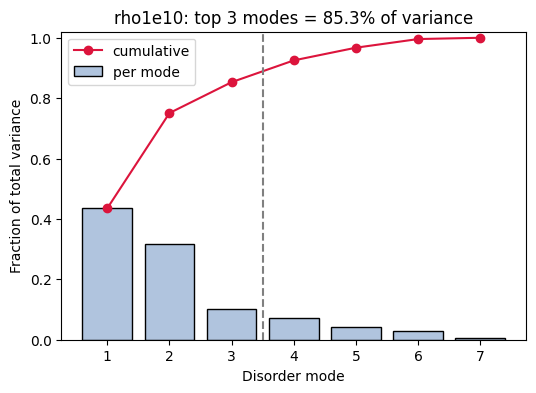

In [3]:
pca_full = ct.PCAModel.fit(raw, n_components=3)

fig, ax = plt.subplots(figsize=(6, 4))
ct.plot_explained_variance(pca_full, ax=ax)
ax.set_title(f"{DATASET}: top 3 modes = {pca_full.explained_variance_ratio[:3].sum():.1%} of variance")

### What the three dominant modes do

Read each column of the heat map as a physical distortion of the device:

- **Mode 1 — symmetric squeeze/stretch.** `d`, `tcs` and `Lxavg` move together:
  the dots are pushed apart *and* the barrier grows. The single biggest source of
  device-to-device variability.
- **Mode 2 — asymmetric tilt.** `dLx`, `dF` and `eps` move together: the left and
  right dot become different, which detunes the qubit.
- **Mode 3 — common vertical shift.** Dominated by `Favg`: the whole potential
  moves in `z`.

Text(0.5, 1.0, 'Disorder modes')

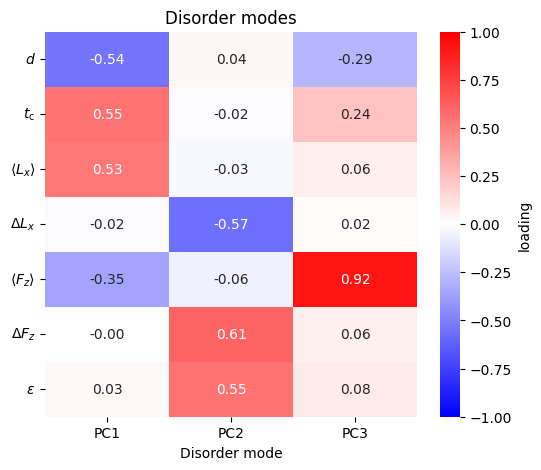

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
ct.plot_mode_loadings(pca_full, n_modes=3, ax=ax)
ax.set_title("Disorder modes")

## Fit both models

In [5]:
gauss = ct.GaussianModel.fit(raw)                 # A
pca = ct.PCAModel.fit(raw, n_components=3)        # B

samples = {
    "Covariance": gauss.sample(N_SAMPLES, seed=SEED),
    "PCA": pca.sample(N_SAMPLES, seed=SEED),
}
samples["PCA"].head()

,d,tcs,Lxavg,dLx,Favg,dF,eps
0,88.049739,99.835161,23.926453,0.106682,5.177774,-0.001066,-0.101917
1,88.612345,96.437198,23.911959,0.373529,5.175956,-0.005646,-0.644857
2,81.725335,142.541925,24.692492,-0.655947,5.157536,0.009827,1.214822
3,100.543588,25.049477,22.902791,0.459457,5.182506,-0.006700,-0.904982
4,112.209591,-41.884891,22.062601,0.198772,5.178362,-0.002986,-0.622333


## The comparison (Fig. 5 of the paper)

Blue = the real COMSOL ensemble, red = method A, yellow = method B. Method A
tracks the raw cloud everywhere. Method B reproduces the dominant correlations
but collapses the residual scatter — visible as a thinner cloud in the pairs that
depend on the discarded modes.

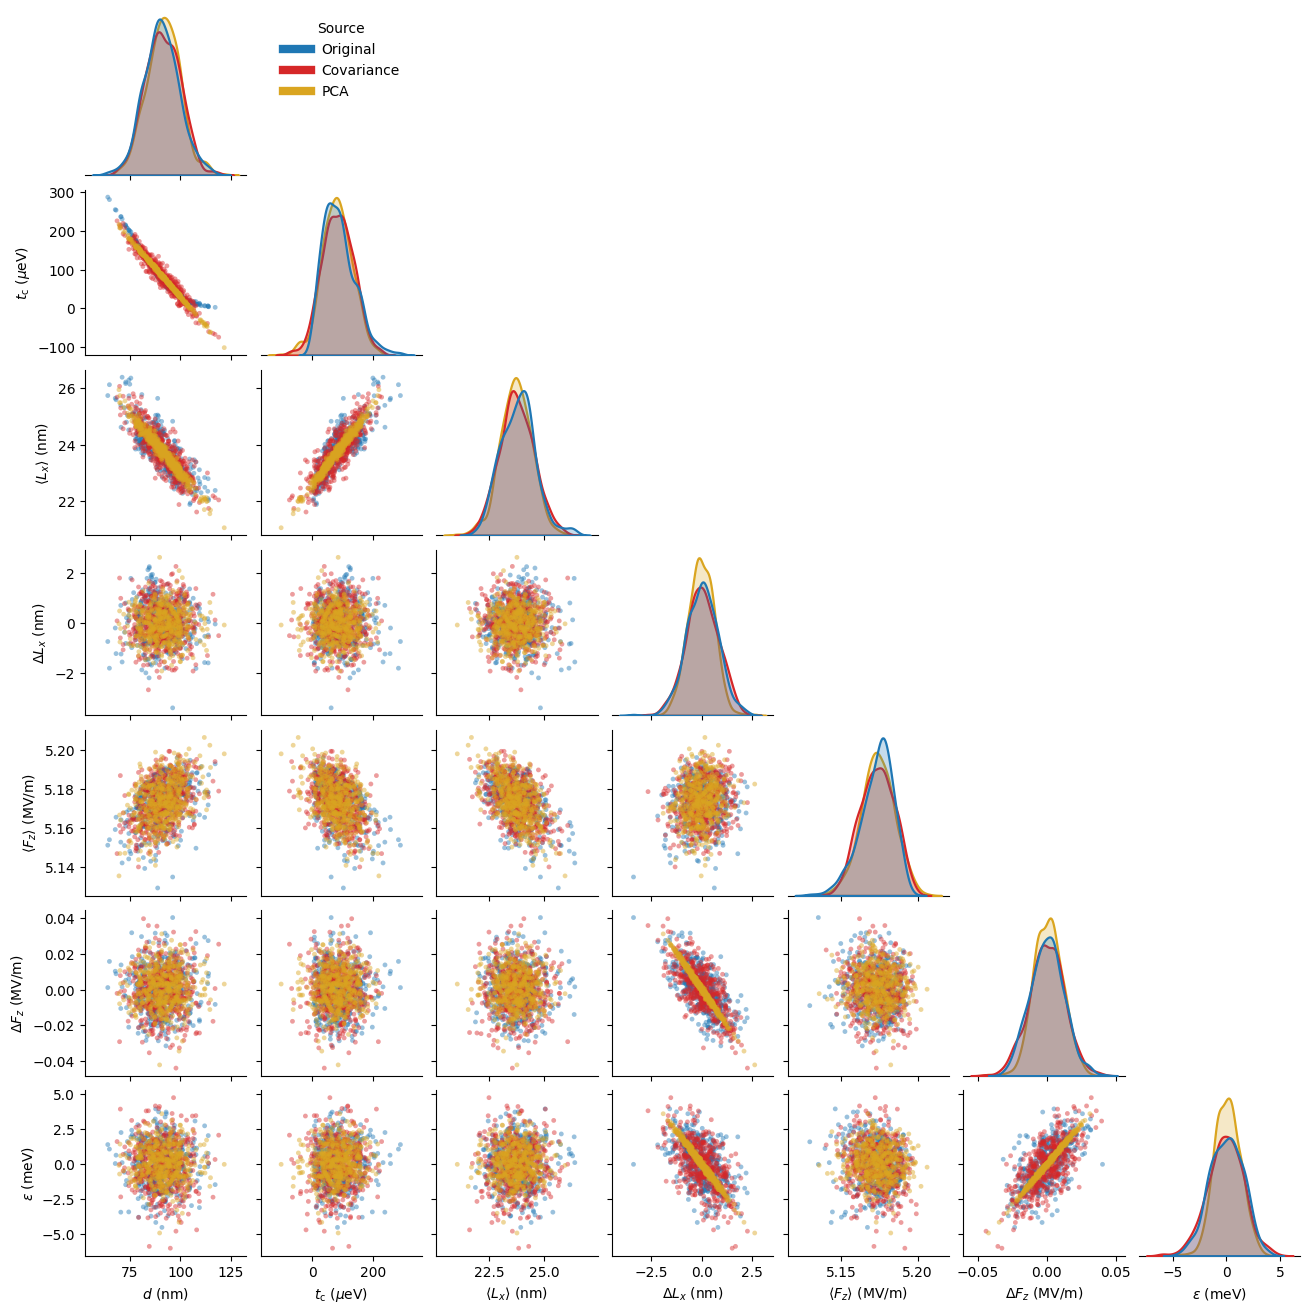

In [6]:
g = ct.pairplot_compare(raw, samples)

## Quantitatively

`ks` is the Kolmogorov–Smirnov distance between a generated marginal and the raw
one (0 = identical). `cov_rel_error` is the relative Frobenius error of the full
covariance matrix — this is where truncating the PCA costs you.

In [7]:
ct.marginal_summary(raw, samples).round(3)

,raw_mean,raw_std,Covariance_mean,Covariance_std,Covariance_ks,Covariance_ks_p,PCA_mean,PCA_std,PCA_ks,PCA_ks_p
parameter,,,,,,,,,,
d,90.510,8.726,91.196,8.568,0.064,0.265,91.585,8.331,0.078,0.106
tcs,86.592,51.952,82.963,51.394,0.053,0.507,80.234,49.720,0.055,0.458
Lxavg,23.803,0.791,23.748,0.780,0.064,0.272,23.709,0.715,0.084,0.067
dLx,0.014,0.792,0.022,0.803,0.039,0.852,-0.036,0.641,0.084,0.066
Favg,5.173,0.011,5.173,0.011,0.060,0.350,5.174,0.011,0.058,0.390
dF,-0.000,0.012,-0.000,0.013,0.030,0.975,0.001,0.010,0.084,0.067
eps,-0.015,1.546,-0.104,1.667,0.035,0.915,0.075,1.222,0.108,0.007


In [8]:
ct.covariance_error(raw, samples).round(3)

,cov_rel_error,corr_rel_error
model,,
Covariance,0.022,0.062
PCA,0.083,0.271


### The trade-off, as a curve

More retained modes = smaller covariance error, at the cost of a bigger model.
Method A is the `k = p` limit.

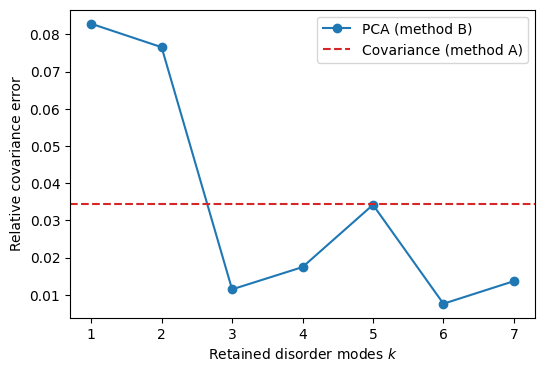

In [9]:
rows = []
for k in range(1, len(PARAMS) + 1):
    s = pca.with_n_components(k).sample(2000, seed=SEED)
    err = ct.covariance_error(raw, {"pca": s}).loc["pca", "cov_rel_error"]
    rows.append({"n_components": k, "cov_rel_error": err})
gauss_err = ct.covariance_error(raw, {"g": gauss.sample(2000, seed=SEED)}).loc["g", "cov_rel_error"]

curve = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(curve.n_components, curve.cov_rel_error, "o-", label="PCA (method B)")
ax.axhline(gauss_err, ls="--", c="tab:red", label="Covariance (method A)")
ax.set_xlabel("Retained disorder modes $k$")
ax.set_ylabel("Relative covariance error")
ax.legend()

## Save the fits

The `.npz` files hold only the fitted numbers (mean, covariance / modes), so
notebook 3 can generate devices without ever touching the raw ensemble.

In [10]:
gauss.save(ct.data.DATA_ROOT / "models" / f"{DATASET}_gaussian.npz")
pca.save(ct.data.DATA_ROOT / "models" / f"{DATASET}_pca3.npz")

PosixPath('/Users/krzywdaja/openspin-repos/ChargeTwin/data/models/rho1e10_pca3.npz')

Next: **`03_cooling_rounds.ipynb`** — the point of all this: many realizations of
the disorder, i.e. many cooldowns.